# Spatial Data Science - Assignment 3
Alessandro Dell'Orto - 6129161

# Task 0

## Problem statement

<br>

**Hypothesis**

In many countries a higher presence of childcare facilities and services is proved to allow for a higher employment rate in women. This could be explained by the fact that in most opposite-sex families, mothers have the the higher burden of raising children. In rural areas, a low access to mother and child health services, early education and screening could prevent mothers to start or continue working. My analysis wants to assess wether in India, a **correlation between the presence of childcare facilities and female employment** rate exists.

Measurements for assessing the correlation are
1. 'Presence of childcare facilities'
2. 'Female employment rate'

<br>

**Goals**

This analysis builds on the same hypothesis of **Assignment 2**.
<br>
However, in the conclusions of that assignment I stated that "_the figures clearly show that the hypothesis is not accepted, but to explore the causes a new analysis with more variables could be performed_".

Indeed, two reasons could have led to the hypothesis to be rejected:
- The measurements are _not correlated_
- The assumptions made were too strong, which led to _false rejection_

I intend to start this assignment by enhancing my assumptions and variable choices to **reduce the chances of a false rejection**.

<br>

**Changes from Assignment 2**

In Assignment 2, the following choices were made
- Presence of childcare facilities was only assessed at village level
- Female employment rate was measured as a ratio with male or total employment

However, false rejection of the hypothesis could come from
- Lower presence of childcare facilities in villages is compensated by centers in towns closeby
- Big differences in population between subdistricts

For these reasons, this analysis will incorporate the following changes
- Inclusion of data at town level
- Scaling of data according to population

The analysis will be performed at district level instead of subdistrict for visualization purposes.

<br>

**Variables Choice**

As chosen within Assignment 2, presence of childcare facilities is measured with the _number of Maternity And Child Welfare Centres_ in the district (centers that focus on mothers and childern's health, children early education, and community outreach) now both at village and town level. Female employment rate is now also measured as a _ratio between employed female population over total female population_.

<br>

**Variables overview**

To perform this analysis we need to access the following variables from SHRUG:


|        |  Variable name (from SHRUG)                           |  Variable code     | SHRUG Table                           | Year   |
| ------ |  ---------------------------------------------------  |  ----------------  |  -----------------------------------  |  ----  |
| **1**  |  District ID                                          |  pc11_d_id         |  PC11 Subdistrict Polygons            |  2011  |
| **2**  |  District Name                                        |  d_name            |  PC11 Subdistrict Polygons            |  2011  | 
| **3**  |  Female Population                                    |  pc11_pca_tot_f    |  Population Census Abstract           |  2011  |
| **4**  |  Maternity And Child Welfare Centre                   |  pc11_vd_mcw_cntr  |  Population Census Village Directory  |  2011  |
| **5**  |  Number of urban maternity and child welfare centres  |  pc11_td_mc_w_ctr  |  Population Census Town Directory     |  2011  |
| **6**  |  Total non-farm employment (2013)                     |  ec13_emp_all      |  Economic Census                      |  2013  |
| **7**  |  Female employment count                              |  ec13_emp_f        |  Economic Census                      |  2013  |
| **8** |  Male employment count                                |  ec13_emp_m        |  Economic Census                      |  2013  |


<br>The analysis will also use combinations of these variables. 
- The total number of childcare centers in the district (village + town)
- Total number of childcare centers over female population
- Employed women over employed men ratio
- Employed women over total employed people
- Employed women over total female population

It is also useful to change some codes to make the coding process easier. The working DataFrame will then have the following structure

|        |  Variable code  (SHRUG)  |  Variable code (new) | Description                                     |  Type         |
| ------ |  ----------------------  |  ------------------  |  ---------------------------------------------  |  -----------  |
| **1**  |  pc11_d_id               |  d_id                |  District ID                                    |  ID           |
| **2**  |  d_name                  |  d_name              |  District Name                                  |  Auxiliary    |
| **3**  |  pc11_pca_tot_f          |  pop_f               |  Total female population                        |  Auxiliary    |
| **4**  |  pc11_vd_mcw_cntr        |  ctr_vil             |  Maternity And Child Welfare Centres (Village)  |  Independent  |
| **5**  |  pc11_td_mc_w_ctr        |  ctr_twn             |  Maternity And Child Welfare Centres (Town)     |  Independent  |
| **6**  |  -                       |  ctr_sum             |  Maternity And Child Welfare Centres (Total)    |  Independent  |
| **7**  |  -                       |  ctr_rat             |  Childcare Centers / Female population          |  Independent  |
| **8**  |  ec13_emp_all            |  emp_t               |  Employed population                            |  Auxiliary    |
| **9**  |  ec13_emp_f              |  emp_f               |  Employed female                                |  Dependent    |
| **10** |  ec13_emp_m              |  emp_m               |  Employed male                                  |  Auxiliary    |
| **11** |  -                       |  emp_fm              |  Employed female/male ratio                     |  Dependent    |
| **12** |  -                       |  emp_ft              |  Employed female/total ratio                    |  Dependent    |
| **13** |  -                       |  emp_fp              |  Employed/Total female                          |  Dependent    |

<br>

We can discern between four different variable types:
- **ID:** the variables we use to associate each entry to a geographic instance (NOTE: our main ID will be the subdistrict as entries are given at that level)
- **Independent:** our independent variable is the number of chlidcare centers
- **Dependent:** the measurement we expect to vary if the independent variable varies is female employment, either by itself, with respect of total/male employment or with respect of female total population
- **Auxiliary:** variables that are not related with the independent variable themselves but are necessary to show an eventual correlation. (except for d_name, which is used for visualization purposes)

<br>

**Considerations**

Even if variables choice was enhanced in some way, a few critical relevant considerations still have to be made:

Firstly, it's unclear wether Maternity and Child Welfare Centers are sufficient representation of childcare facilities, as they are primarily health centers, so the measurement does not account for early education, which access probably has a great impact on female employment rate. Secondly, many women, especially in disadvantaged areas, could be working off the book, meaning they are not counted in the employment rate, distorting the analysis. The employment rate variable could then be seen as a proxy for the actual amount of working women in the area.

Last but not least, the analysis implicitly applies a normative value to the variables. High levels of both variables are considered "good" or "desirable". The analysis will consider of more interest those areas in which values are very high or very low.
<br>
Indeed, values that are high when compared to the average values of the dataset, could be considered low values in other contexts. What makes a value (of emplyment for example, or availabililty of childcare centers) high, is subjective for the analyst and the context and therfore the term should be used carefully when communicating the results of the analysis or identifying improvement strategies.

## Critical Data Science Perspective

- **Design Choices:** in the Hague's dataset, used for Assignment 1, data on Socio-economic indicators and Education indicators was given on different geographical levels. Data on school personnel, for example, was not given on neighbourhood level. This meant that to assess the dependant variable a lot of assumptions had to be made. In SHRUG, both data for the number of maternity and child care centers and employed men and women is available at subdistrict level. This means that less assumptions and corrections have to be made. However, data on care centers is extracted from the 2011 population census while employment numbers are extracted from 2013 economic census. On the other end, the Hague's data had a contious time span over a few decades, allowing for trend analysis. If you were to perform a trend analysis on SHRUG, you could only rely on a few censuses. Moreover, as variables refer to two different years, the eventual correlation will inevitably be less precise.
- **Independent variables:** assuming that some mothers stay on the job market only if they have access to childcare services, the number of Mother and Child Care Centers is the independent variable.
- **Missing variables:** as already mentioned, those centers do not account to all early welfare facilities, and for example, the datasets do not contain information on kindergardens or other early education facilities. At the same time, female employment numbers don't account for off-the-book workers. Both variables are then subject to slight sumptions and approximations.
- **Rejection:** the assumption could be rejected if other factors account for female employment, like the composition of the job market or proximity of the working place.
- **False rejection:** the assumption could be falsely rejected if women highly work off the books, meaning that chnges depending on the presence of childcare facilities are not measurable.
- **False acceptance:** the assumption could be falsely accepted if, instead, both variables are correlated to another. For example, areas could have big differences in fertility, and women decide to keep working not because they have access to facilities but because they decide not to have kids at all. A deeper analysis woud use the fertility rate as a control variable.
- **Perspectives:** this hypothesis makes some assumptions on the reliance of data, on the importance of childcare facilities over other public infrastructures and welfare services. As seen in the previous points, the outcomes of the analysis could be distorted by some of the factors that were not taken into consideration in the hypothesis formulation.

**NOTE** the difference in year of the two variables could lead to both false rejection or acceptance due to big changes happening over the years (e.g. big investments in childcare facilities, peak in employment rates)

---

In [93]:
# 1. Standard library imports
import os
os.environ["OMP_NUM_THREADS"] = '3'#We need to change this value before importing sklearn libraries
#Otherwise we'll recieve a warning during clustering process
import random

# 2. Third-party libraries
import contextily as ctx
import geopandas as gpd
import mapclassify
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import palettable as pltt
import pandas as pd
import pysal as ps
import scipy as sp
import seaborn as sns
from matplotlib.lines import Line2D
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot, lisa_cluster, plot_local_autocorrelation
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import cluster

%matplotlib inline

**NOTE:** we are not using spaghetti for our network analysis, so the warning does not impact our code

---

## Import and format data

First, we download the datasets of interest from SHRUG 2.1

1. 2013 Economic Census
2. 2011 Population Census Abstract
3. 2011 Population Census Town Directory
4. 2011 Population Census Village Directory


<br>

**NOTE:** we need the Population Census Abstract (PCA) folder for the female population variable. This data is also present in the other Population Census directories, however, the SHRUG guide states that: 

"_In some cases, the Census shows inconsistencies between rural PCA population and village directory population, or between urban PCA and town directory; we advise using the population from the PCA_"


<br>

We can now read each csv file and put its content in a different pandas DataFrame

In [2]:
df1 = pd.read_csv("data/shrug-pca11-csv/pc11_pca_clean_pc11dist.csv")
df2 = pd.read_csv("data/shrug-td11-csv/pc11_td_clean_pc11dist.csv")
df3 = pd.read_csv("data/shrug-vd11-csv/pc11_vd_clean_pc11dist.csv")
df4 = pd.read_csv("data/shrug-ec13-csv/ec13_pc11dist.csv")

We will merge each dataframe by the District ID (pc11_district_id). We can then start isolating the variables we need for our analysis for each dataset <br>

**df1**
- District ID
- Total female population

**df2**
- District ID
- Maternity And Child Welfare Centres (Town)

**df3**
- District ID
- Maternity And Child Welfare Centres (Village)

**df4**
- District ID
- Employed population
- Employed female
- Employed male

In [3]:
df1 = df1[["pc11_district_id","pc11_pca_tot_f"]]
df2 = df2[["pc11_district_id","pc11_td_mc_w_ctr"]]
df3 = df3[["pc11_district_id","pc11_vd_mcw_cntr"]]
df4 = df4[["pc11_district_id","ec13_emp_all","ec13_emp_f","ec13_emp_m"]]

<br>Now we can download and read in jupiter the District polygons from Population census 2011

In [4]:
gdf = gpd.read_file("data/shrug-pc11dist-poly-shp/district.shp")

The column names for the geodataframe IDs are different. We can rename them to make them match the other dataframes. 
When we'll have the final geo-dataframe we'll rename all the variables with the chosen codes.

In [5]:
gdf.rename(columns={'pc11_d_id':'pc11_district_id'}, inplace=True)

Before merging, we see that the subdistrict ID of the dfs are a different type from the gdf.

In [6]:
dfs = [df1, df2, df3, df4]

#Print the data type of the district ID column for each df and the gdf
print("\n".join([f"df{i+1}: {df.pc11_district_id.dtype}" for i, df in enumerate(dfs)]))
print(f"gdf: {gdf.pc11_district_id.dtype}")

df1: int64
df2: int64
df3: int64
df4: int64
gdf: object


We fix this by changing the codes' type in the geopandas dataframe.

In [7]:
gdf.pc11_district_id = gdf.pc11_district_id.astype('int64')

<br>Now, we want all dfs to have a single entry for each district. Let's see if this is the case

**NOTE:** It's important to check this before the merging, otherwise the number of eventual duplicate entries per subdistrict will increase even more in the merged dataframe.

In [8]:
#Print True if the district ID column has any duplicate value, False otherwise
print("\n".join([f"df{i+1}: {df.pc11_district_id.duplicated().any()}" for i, df in enumerate(dfs)]))
print(f"gdf: {gdf.pc11_district_id.duplicated().any()}")

df1: False
df2: False
df3: False
df4: False
gdf: False


We don't have any duplicates.
<br>
Now, we are interested in those districts that can be represented spatially, meaning that they should be present in the gdf. To e sure of this, we select the rows of df1 to df4 that have IDs that are also present in gdf

In [9]:
for df in dfs:
    df = df[df.pc11_district_id.isin(gdf.pc11_district_id)]

Let's check now if we have some missing data.

**NOTE** all data is in int type already so we are not to worry for non numeric values.

In [10]:
#Let's check if we have NaN values in any of the dataframes
print("\n".join([f"df{i+1}: {df.isna().any().any()}" for i, df in enumerate(dfs)]))
print(f"gdf: {gdf.isna().any().any()}")

df1: False
df2: True
df3: False
df4: False
gdf: True


df2 and gdf have some missing entries, let's see where starting from df2

In [11]:
#Check the column for which data is missing
df2.isna().any()

pc11_district_id    False
pc11_td_mc_w_ctr     True
dtype: bool

We miss some entries for the number of town childcare centers. We can assume that those districts have zero centers. We will do the filling later. Now let's check the gdf:

In [12]:
#Check the column for which data is missing
gdf.isna().any()

pc11_s_id           False
pc11_district_id    False
d_name               True
geometry            False
dtype: bool

We have some names missing district name. We can replace them with "Unknown"

In [13]:
gdf.d_name = gdf.d_name.fillna("Unknown")

<br> Having dealt with missing values, we come up with another problem: all dfs are smaller in size than the gdf

In [14]:
#Print the number of rows for each dataframe
print("\n".join([f"df{i+1}: {len(df)}" for i, df in enumerate(dfs)]))
print(f"gdf: {len(gdf)}")

df1: 640
df2: 635
df3: 631
df4: 640
gdf: 641


If we perform merging with default parameters we will lose several entries, because the final df will only have entries which ID is present in all of the dfs. This means that at least 15 districts will be lost.

df2 and df3 include the number of childcare centers. To Avoid losing rows, we can assume again that missing districts have zero centers. To do so, we apply the merging by setting the parameter "how" to "left", meaning that missing rows from df2 and df3 will be filled with NaN values. Afterwards, we will fill those values with zeros.

We cannot do the same with df4 as its very farfetched to assume that districts have zero employed people. But we can afford to lose one row.

In [15]:
geo = gdf.merge(df1, on="pc11_district_id") # we start with gdf to make sure that the final dataframe is a geo dataframe
geo = geo.merge(df2, on="pc11_district_id", how='left') #fill df2 columns with NaN for its missing rows
geo = geo.merge(df3, on="pc11_district_id", how='left')
geo = geo.merge(df4, on="pc11_district_id")

geo.head()

,pc11_s_id,pc11_district_id,d_name,geometry,pc11_pca_tot_f,pc11_td_mc_w_ctr,pc11_vd_mcw_cntr,ec13_emp_all,ec13_emp_f,ec13_emp_m
0,24,468,Kachchh,"MULTIPOLYGON (((70.45008 23.01226, 70.44904 23...",995634,10.0,66.0,238573.0,36129.0,202444.0
1,24,469,Banas Kantha,"MULTIPOLYGON (((71.24964 24.20926, 71.24207 24...",1510127,9.0,0.0,164449.0,27869.0,136580.0
2,24,470,Patan,"MULTIPOLYGON (((71.42507 23.96967, 71.42497 23...",649337,2.0,64.0,93613.0,16009.0,77604.0
3,24,471,Mahesana,"POLYGON ((72.79975 24.07615, 72.80022 24.07529...",978544,8.0,0.0,173800.0,23359.0,150441.0
4,24,472,Sabar Kantha,"POLYGON ((73.14784 24.47759, 73.14773 24.4741,...",1184358,10.0,85.0,142292.0,34127.0,108165.0


As expected, the merged dataframe has lost just one row compared to the geodataframe

In [16]:
len(geo)

640

---

## Check and clean data

Let's start by changing the column names to the variable names we chose at the beginning

In [17]:
geo.columns = ["s_id","d_id","d_name","geometry","pop_f","ctr_twn","ctr_vil","emp_t","emp_f","emp_m"]

Let's doublecheck that there are no duplicated districts

In [18]:
geo.d_id.duplicated().any()

False

Let's print some information on our working dataframe: shape, types, columns, missing values

In [19]:
geo.shape

(640, 10)

In [20]:
geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   s_id      640 non-null    object  
 1   d_id      640 non-null    int64   
 2   d_name    640 non-null    object  
 3   geometry  640 non-null    geometry
 4   pop_f     640 non-null    int64   
 5   ctr_twn   634 non-null    float64 
 6   ctr_vil   631 non-null    float64 
 7   emp_t     640 non-null    float64 
 8   emp_f     640 non-null    float64 
 9   emp_m     640 non-null    float64 
dtypes: float64(5), geometry(1), int64(2), object(2)
memory usage: 50.1+ KB


In [21]:
geo.iloc[:,2:].describe() #We start from column 2 because we don't care about data for district ID

,pop_f,ctr_twn,ctr_vil,emp_t,emp_f,emp_m
count,6.400000e+02,634.000000,631.000000,6.400000e+02,640.000000,6.400000e+02
mean,9.180146e+05,8.917981,56.898574,1.717703e+05,38721.315625,1.330490e+05
std,7.448035e+05,16.084185,103.079315,2.185740e+05,55555.267999,1.698076e+05
min,3.590000e+03,0.000000,0.000000,7.430000e+02,274.000000,4.690000e+02
25%,4.017458e+05,2.000000,10.000000,5.397450e+04,10567.000000,4.284700e+04
50%,7.589200e+05,4.000000,36.000000,1.026000e+05,20277.500000,8.346300e+04
75%,1.264277e+06,9.000000,66.000000,1.941972e+05,39264.750000,1.565212e+05
max,5.195070e+06,214.000000,1794.000000,1.667968e+06,434628.000000,1.342796e+06


In [22]:
geo.count()

s_id        640
d_id        640
d_name      640
geometry    640
pop_f       640
ctr_twn     634
ctr_vil     631
emp_t       640
emp_f       640
emp_m       640
dtype: int64

As we expected, we have missing values for number of childcare centers in towns and villages. Let's fill those with zeros

In [23]:
geo["ctr_twn"] = geo["ctr_twn"].fillna(0, inplace=False)
geo["ctr_vil"] = geo["ctr_vil"].fillna(0, inplace=False)

#Now the dataframe has no missing value
geo.isna().any().any()

False

We can also notice that ctr_twn and ctr_vil are of float type. However, the number of childcare centers in a subdistrict will always be integer. We can convert them to int type: this will save us from having to make some adjustments during the visualization phase

In [24]:
geo.ctr_twn = geo.ctr_twn.astype('int64')
geo.ctr_vil = geo.ctr_vil.astype('int64')

Let's see now if visualization works properly

<Axes: >

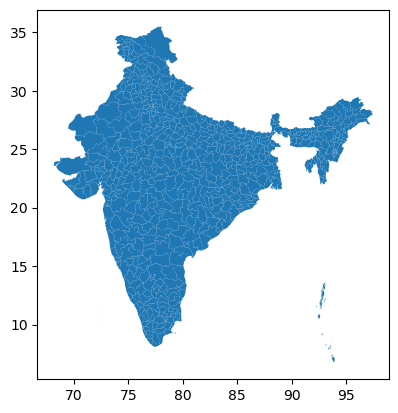

In [25]:
geo.plot()

Last thing to do before starting EDA is to add the auxiliary variables we defined in the problem statement

In [26]:
geo["ctr_sum"] = geo.ctr_twn + geo.ctr_vil
geo["ctr_rat"] = geo.ctr_sum / geo.pop_f
geo["emp_fm"] = geo.emp_f/geo.emp_m
geo["emp_ft"] = geo.emp_f/geo.emp_t
geo["emp_fp"] = geo.emp_f/geo.pop_f

In [27]:
#We reorder columns for practicality
geo = geo[["d_id","d_name","s_id","pop_f",
           "ctr_twn","ctr_vil","ctr_sum","ctr_rat",
           "emp_t","emp_f","emp_m","emp_fm","emp_ft","emp_fp",
           "geometry"]]

In [28]:
#This is what our working dataframe looks like now
geo.head()

,d_id,d_name,s_id,pop_f,ctr_twn,ctr_vil,ctr_sum,ctr_rat,emp_t,emp_f,emp_m,emp_fm,emp_ft,emp_fp,geometry
0,468,Kachchh,24,995634,10,66,76,0.000076,238573.0,36129.0,202444.0,0.178464,0.151438,0.036287,"MULTIPOLYGON (((70.45008 23.01226, 70.44904 23..."
1,469,Banas Kantha,24,1510127,9,0,9,0.000006,164449.0,27869.0,136580.0,0.204049,0.169469,0.018455,"MULTIPOLYGON (((71.24964 24.20926, 71.24207 24..."
2,470,Patan,24,649337,2,64,66,0.000102,93613.0,16009.0,77604.0,0.206291,0.171013,0.024654,"MULTIPOLYGON (((71.42507 23.96967, 71.42497 23..."
3,471,Mahesana,24,978544,8,0,8,0.000008,173800.0,23359.0,150441.0,0.155270,0.134402,0.023871,"POLYGON ((72.79975 24.07615, 72.80022 24.07529..."
4,472,Sabar Kantha,24,1184358,10,85,95,0.000080,142292.0,34127.0,108165.0,0.315509,0.239838,0.028815,"POLYGON ((73.14784 24.47759, 73.14773 24.4741,..."


---
# Task 1

## Exploratory Data Analysis



### Introduction

In this section we will make some visualization with the variables we loaded or built in our dataframe. To assess which types of visualization we should be using, we can rely on the guidance given by the website [_from data to Viz_](https://www.data-to-viz.com/)

Our analysis is focused on
- Numeric data
- Two numeric variables
- Not ordered
- More than 2000 entries

Following the website's chart, we can make these kinds of plots
- Violin plot
- Density plot
- Scatterplot with marginal point
- 2D density plot

As mentioned in the problem statement, possible false rejection of the hypothesis could come from using absolute number of employed women per subdistrict. It could make sense then to consider the ratio between employed women and female population. To be sure this make sense, we can see if the number of employed women has a positive correlation with female population in the subdistrict.

However, it could also be the case with the number of childcare centers (the more women, the more childcare centers), meaning that we would have to also scale the number of centers with the female population.

To have a clearer picture of this, we can plot the scatterplots of those variables with their regression line

In [29]:
# set seaborn style
sns.set_theme()

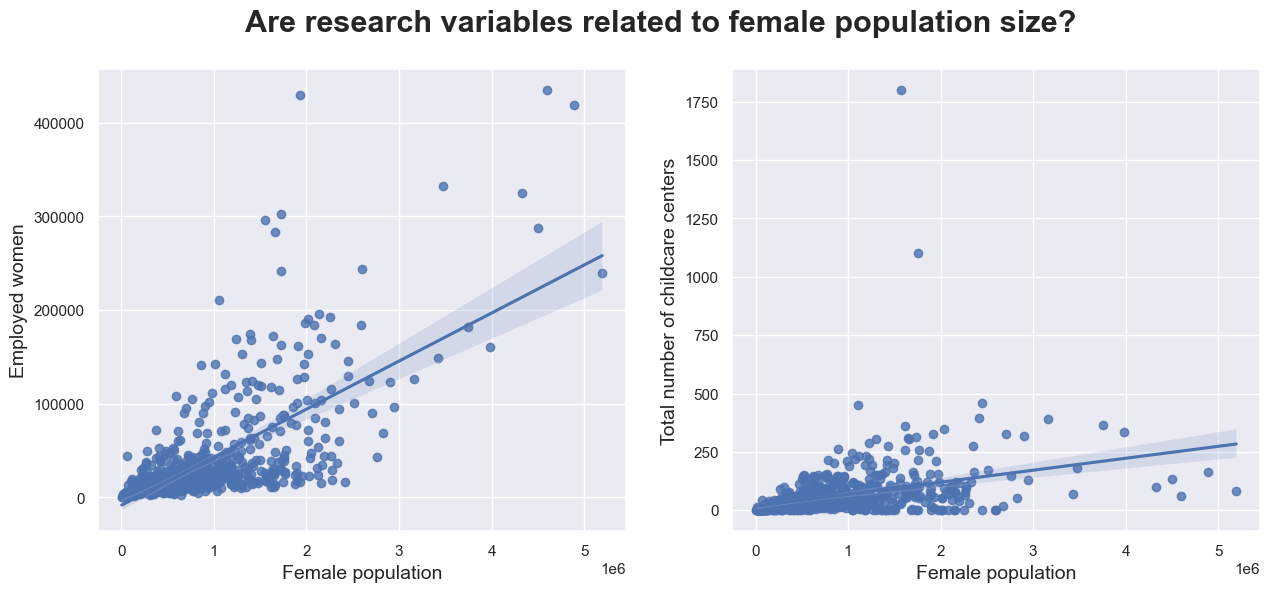

In [30]:
f, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.regplot(data=geo, x="pop_f", y="emp_f", ax=ax[0])
ax[0].set_xlabel("Female population", fontsize=14)
ax[0].set_ylabel("Employed women", fontsize=14)

sns.regplot(data=geo, x="pop_f", y="ctr_sum", ax=ax[1])
ax[1].set_xlabel("Female population", fontsize=14)
ax[1].set_ylabel("Total number of childcare centers", fontsize=14)

f.suptitle("Are research variables related to female population size?", 
           fontsize=22,
           fontweight="demibold"
          )
plt.show()

The employed women's scatterplot shows a clear correlation between the two variables (the slope of the linear regression line is positive). 
The second graph shows a weaker correlation: the number of childcare centers could be influenced by other factors.

The analysis is mostly qualitative as values have not been normalised. However, we can still conclude that female population is a factor for both measurements. Also, neither correlation is perfect, so both factors are not 100% reliant on female population. This could mean the hypothesis could still be confirmed and we could assess some spatial correlation for each variable later on.

We can therefore decide to compare the two measurements by using the variables _emp_fp_ and _ctr_rat_ that scale the research values by the female population of the district.

**NOTE:** this could make the analysis more precise but also more distorted. We should ask ourselves a few questions:
- **Was female population measured correctly for each district?** Poorer areas could have unreported census.
- **Economic data on employment comes from 2013 and not 2011, does this bring a big distrortion to the results?**

<br>Let's follow DataToViz reccomendation and make a scatterplot of the two variables to see if we can immediately spot a correlation

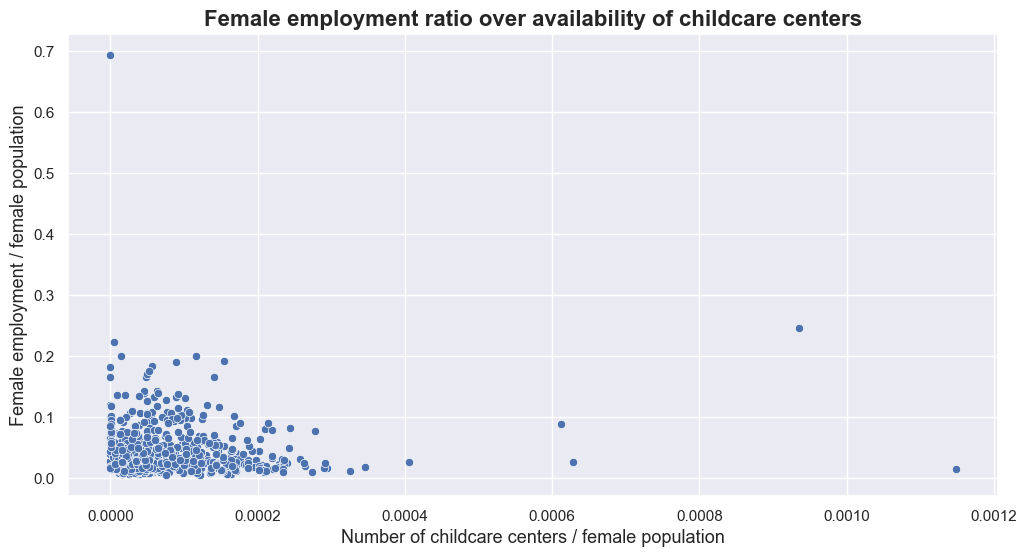

In [31]:
f, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.scatterplot(data=geo, x="ctr_rat", y="emp_fp", ax=ax)

ax.set_xlabel("Number of childcare centers / female population", fontsize=13)
ax.set_ylabel("Female employment / female population", fontsize=13)

ax.set_title("Female employment ratio over availability of childcare centers", fontsize=16, fontweight="demibold")
plt.show()

There seems to be no clear correlation between the two variables. However, visualization is made difficult due to the presence of outliers.

Let's take a look at the distribution of the research variables by plotting the KDE distribution

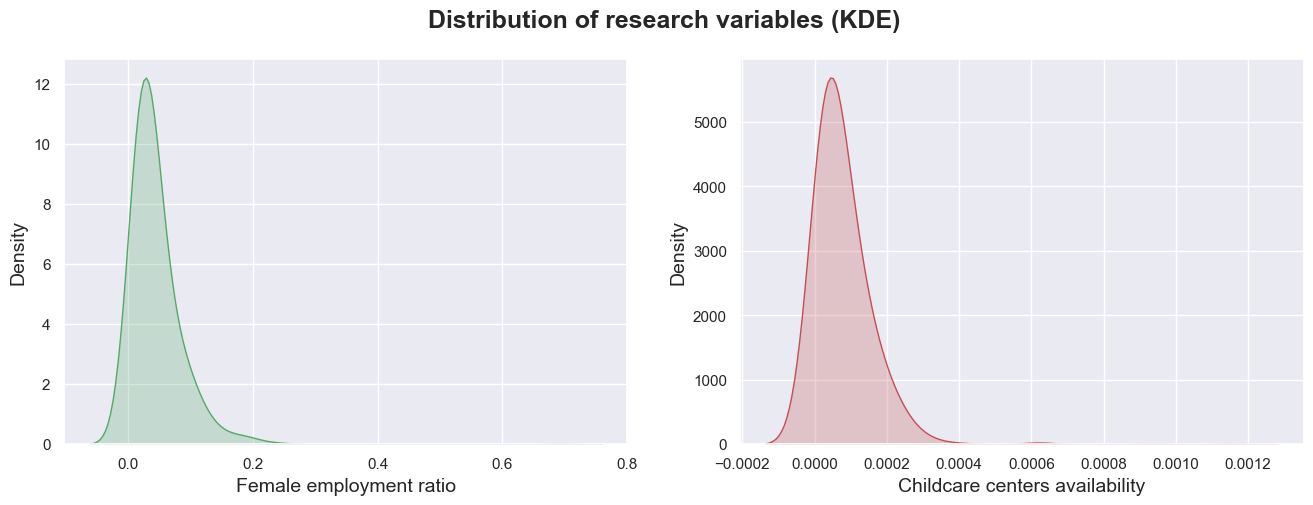

In [32]:
f, ax = plt.subplots(1, 2, figsize=(16, 5))

#KDE plot for the dependent variable
sns.kdeplot(geo['emp_fp'], bw_method=0.5, label="bw: 0.5", fill=True, color="g", ax=ax[0])
ax[0].set_xlabel("Female employment ratio", fontsize=14)
ax[0].set_ylabel("Density", fontsize=14)

#KDE plot for the independent variable
sns.kdeplot(geo['ctr_rat'], bw_method=0.5, label="bw: 0.5", fill=True, color="r", ax=ax[1])
ax[1].set_xlabel("Childcare centers availability", fontsize=14)
ax[1].set_ylabel("Density", fontsize=14)

#Title
f.suptitle("Distribution of research variables (KDE)", 
           fontsize=18,
           fontweight="demibold"
          )
plt.show()

We can get rid of the outliers by subsetting the dataframe. We do so by looking at the KDE plots and chose a threshold visually that preservs most of the data

In [33]:
#Choose the threshold
threshold_x = 0.18
threshold_y = 0.0003

#Create a subsetted dataframe
subset = geo[(geo["emp_fp"] < threshold_x) & (geo["ctr_rat"] < threshold_y)]

Let's see if a scatterplot of the subsetted df gives us more visual information

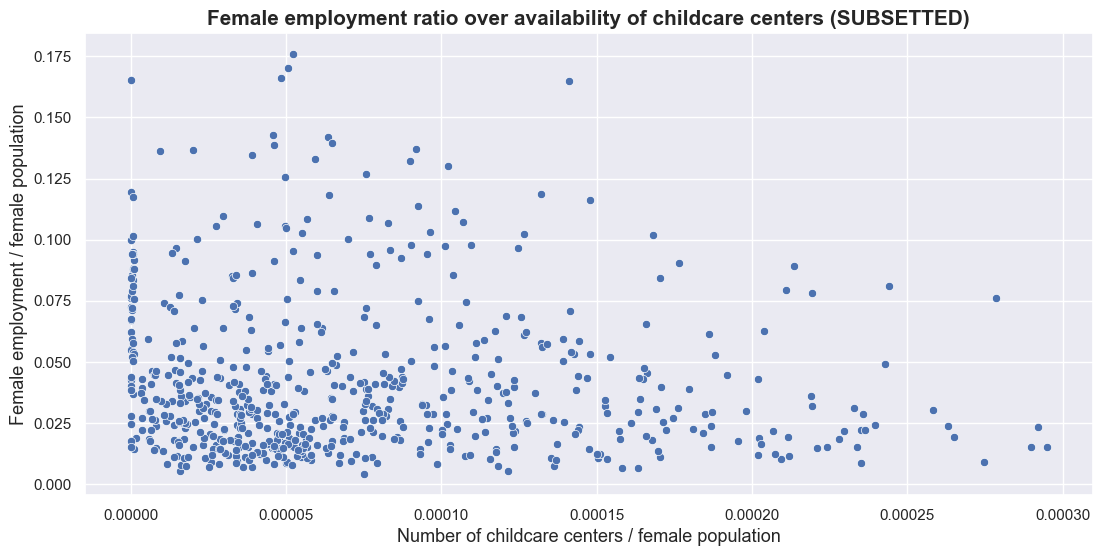

In [34]:
f, ax = plt.subplots(1, 1, figsize=(13, 6))

sns.scatterplot(data=subset, x="ctr_rat", y="emp_fp", ax=ax)

ax.set_xlabel("Number of childcare centers / female population", fontsize=13)
ax.set_ylabel("Female employment / female population", fontsize=13)

ax.set_title("Female employment ratio over availability of childcare centers (SUBSETTED)", fontsize=15, fontweight="demibold")
plt.show()

**What we notice**
- There is no strong positive correlation
- We have fewer data for high values of the independent variable
- Many districts have zero childcare centers and high variance of employment: could that be due to how we cleaned the data?


We can move on with the analysis to make some more meaningful visualization: we just have to remember that data for districts with 0 childcare centers **could be distorted**.

<br>**Problem:** the fact that we have a lot of entries makes visualization not very easy to follow. Therefore, it could be useful to make some approximations:
- Distribute the independent variables into a number of bins
- Display the average value of the dependent variable for each bin

**NOTE:** Each bin will have a different number of entries: this is important for the validity of the results. We could chose to make bins with quantiles method, but this would make visualization too skewed. 

We therefore decide to make equally spaced bins and display in the plot the number of districts for which the average was calculated

In [108]:
#Assign the number of bins to a variable to make the code easier to modify
n = 20 

# Create the bins and assign each entry to a bin (from 0 to n-1)
subset.loc[:,"ctr_bins"] = pd.cut(subset.ctr_rat, bins=n, labels = range(n))

#We save the size of the bins for later
base = subset["ctr_rat"].max()/n

#Count the number of entries per bin
count = subset["ctr_bins"].value_counts() 

#Create a new subset with the mean value for each bin
viz_df = subset.groupby("ctr_bins", observed=False)["emp_fp"].mean().reset_index().fillna(0, inplace=False)

#Add the number of samples for each bin
viz_df["ctr_cnt"] = count

#This is for visualization purposes: the bin size is very low and the compiler has some problem in rounding it
#We therfore print the values with tho digits and specify the magnitude in the axis label
viz_df.ctr_bins = viz_df.astype(int).ctr_bins*1e4*base

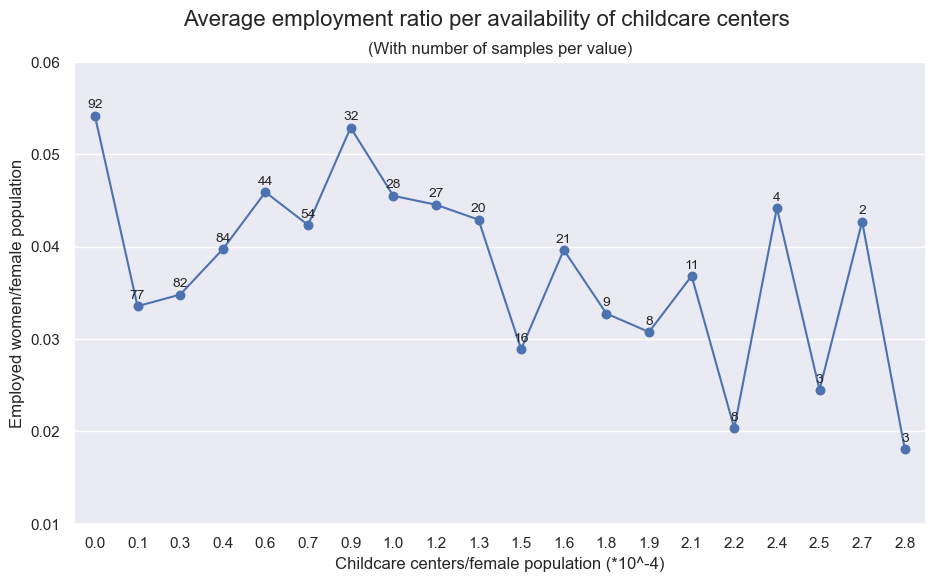

In [36]:
f, ax = plt.subplots(1, 1, figsize=(11, 6))

data = viz_df
data.ctr_bins = viz_df.ctr_bins.round(1) #We round the value to the first decimal digit

# Create the point plot
sns.pointplot(
    data=data,
    x="ctr_bins",
    y="emp_fp",
    linewidth=1.5,
    markersize=6,
    legend=False
)

# Add text labels for each point in the plot
for i, (x, y, label) in enumerate(zip(data["ctr_bins"], data["emp_fp"], data["ctr_cnt"])):
    ax.text(
        i,  # X position: index of the category (using i from enumerate)
        y + 0.0005,  # Y position: slightly above the point
        label,  # Text to display (from the "ctr_cnt" column)
        ha="center",  # Center the label horizontally
        va="bottom",  # Align text above the point
        fontsize=10,  # Font size
    )

#Add lables and titles
ax.set_xlabel("Childcare centers/female population (*10^-4)", fontsize=12)
ax.set_ylabel("Employed women/female population", fontsize=12)
f.text(0.5, 0.95, "Average employment ratio per availability of childcare centers", ha='center', va='center', fontsize=16)
ax.set_title("(With number of samples per value)", fontsize=12)

plt.ylim((0.01,0.06))
plt.show()

**What we notice**
- There is an immediate drop in employment for the first two values: this could be due to the distortion introduced during the cleaning process.
- For low values there is a gradual increase in employment, suggesting a possible correlation
- The growth slows and inverts after one point: however, the values are calculated on less districts
- The final values oscillate a lot due to the fact that the average is calculated on very few entries

Let's see how overall employment changes with the childcare centers availability by making a stacked area plot:

In [37]:
#Add mean values of female and male overall employment for each bin
viz_df[["emp_f","emp_m"]] = subset.groupby("ctr_bins", observed=False)[["emp_f","emp_m"]].mean().reset_index()[["emp_f","emp_m"]]

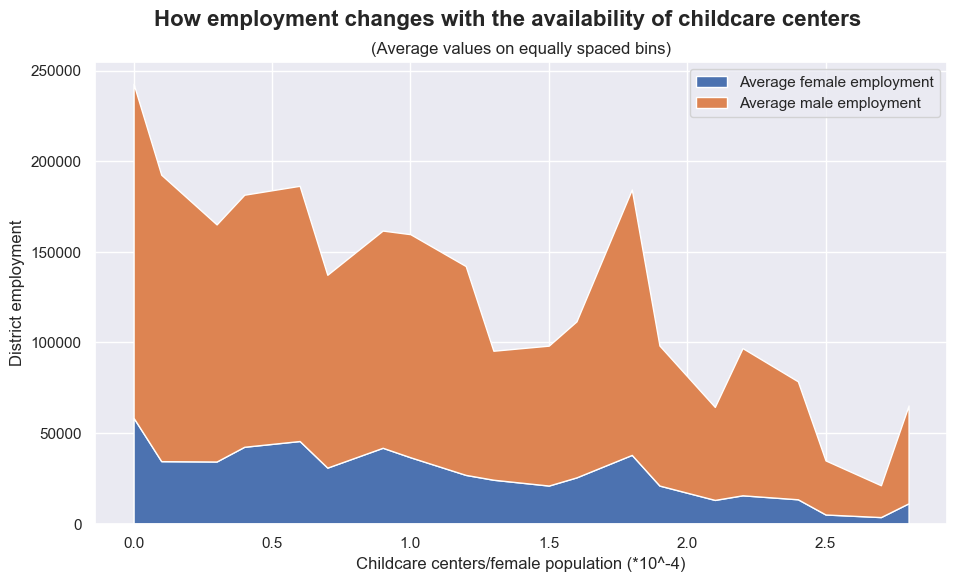

In [38]:
#Make the stack area plot
f, ax = plt.subplots(1, 1, figsize=(11, 6))
x = viz_df["ctr_bins"]
y = [viz_df["emp_f"], viz_df["emp_m"]]
plt.stackplot(x,y, labels=['Average female employment','Average male employment'])

#Add lables and titles
ax.set_xlabel("Childcare centers/female population (*10^-4)", fontsize=12)
ax.set_ylabel("District employment", fontsize=12)
f.text(0.5, 0.95, "How employment changes with the availability of childcare centers", ha='center', va='center', fontsize=16, fontweight="bold")
ax.set_title("(Average values on equally spaced bins)", fontsize=12)
plt.legend(loc='upper right')


plt.show()

**What we notice**
- Total employment drops significantly in a seemingly linear fashon
- Changes female employment over total are difficult to assess

Let's make the drop in total employment clear with a separate plot and also plot the evolution of female employment over the total

In [39]:
#Add mean values of total and female/total overall employment for each bin
viz_df["emp_t"] = subset.groupby("ctr_bins", observed=False)["emp_t"].mean().reset_index()["emp_t"]
viz_df["emp_ft"] = subset.groupby("ctr_bins", observed=False)["emp_ft"].mean().reset_index()["emp_ft"]

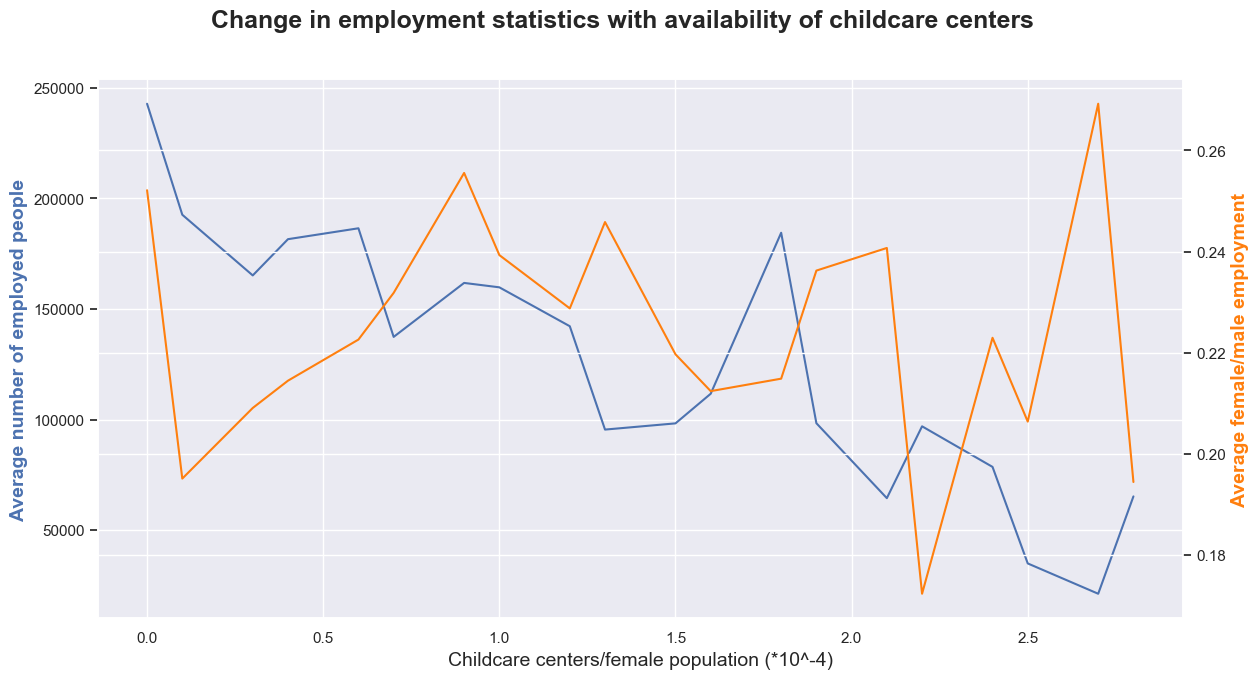

In [40]:


# Create subplots
f, ax1 = plt.subplots(figsize=(14, 7))

# First plot on the first axis (ax1)
line1 = sns.lineplot(data=viz_df, x="ctr_bins", y="emp_t", linewidth=1.5, legend=False, color='b', ax=ax1)
ax1.set_xlabel("Childcare centers/female population (*10^-4)", fontsize=14)
ax1.set_ylabel("Average number of employed people", color='b', fontsize=14, fontweight='bold')

# Create a second y-axis that shares the same x-axis as ax1
ax2 = ax1.twinx()

# Second plot on the second y-axis (ax2)
line2 = sns.lineplot(data=viz_df, x="ctr_bins", y="emp_ft", linewidth=1.5, legend=False, color='tab:orange', ax=ax2)
ax2.set_ylabel("Average female/male employment", color='tab:orange', fontsize=14, fontweight='bold')

# Create proxy artists for the legend
proxy1 = Line2D([0], [0], color='tab:blue', lw=2, label='emp_t')  # Same color as line1
proxy2 = Line2D([0], [0], color='tab:orange', lw=2, label='emp_ft')  # Same color as line2

# Title for the figure
f.suptitle("Change in employment statistics with availability of childcare centers", fontsize=18, fontweight="demibold")

# Show the plot
plt.show()

**What we notice**
- The drop in total employment
- Employment ratio follows a similar trend as the female/total population ratio
<br><br>

**CONCLUSIONS**
- There is no strong correlation between the two variables: however, if we exclude districts with zero centers (whcih again, could be subject to distortion from cleaning), we can notice an initial growth in employment, both over total female population and compared to male. Finally, growth starts to slow down and then oscillates strongly, due to a lack of data.
- Total employment seems to drop steadily when access to childcare center grows. The reason why this happens is not easy to guess.

---
## Spatial Analysis


The easier place to start our spatial analysis is to take a look at the spatial distribution of the two research variables. 
This time, since we are making a spatial visualization, we can easily and conveniently opt for quantiles binning with the help of _Mapclasify_ library

For both research variables, we can show how bins are made on the KDE distribution and the choropleth map

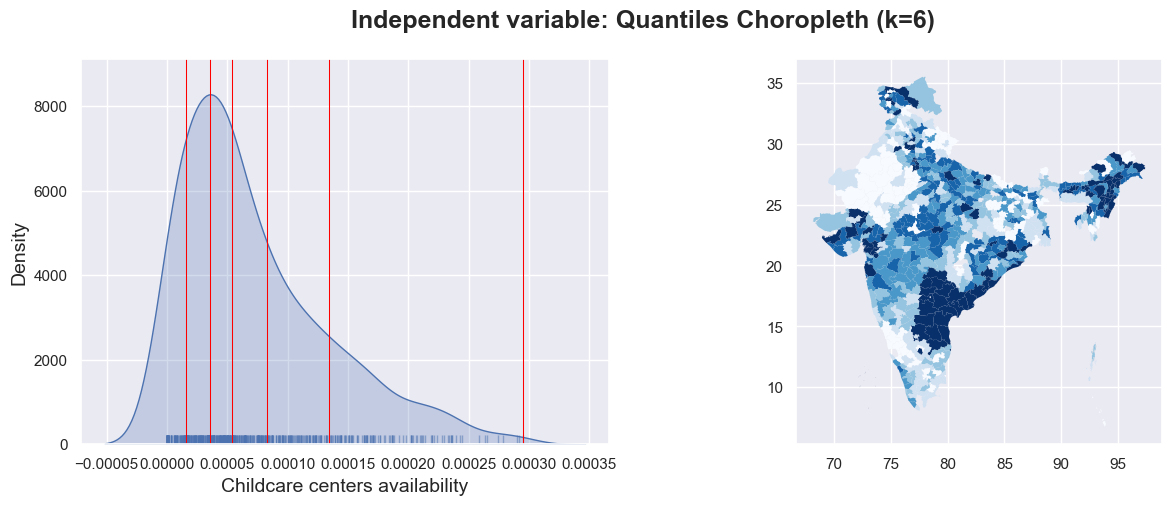

In [41]:
classi = mapclassify.Quantiles(subset["ctr_rat"], k=6)

f, ax = plt.subplots(1, 2, figsize=(15, 5))

#KDE plot for the dependent variable
sns.kdeplot(subset["ctr_rat"], fill=True, ax=ax[0])
# Add a blue tick for every value at the bottom of the plot (rugs)
sns.rugplot(subset["ctr_rat"], alpha=0.5, ax=ax[0])
# Loop over each break point and plot a vertical red line
for cut in classi.bins:
    ax[0].axvline(cut, color="red", linewidth=0.75)
ax[0].set_xlabel("Childcare centers availability", fontsize=14)
ax[0].set_ylabel("Density", fontsize=14)

#KDE plot for the independent variable
subset.plot(column="ctr_rat", scheme="QUANTILES", alpha=1, k=6, cmap=plt.cm.Blues_r, edgecolor="w", linewidth=0, ax=ax[1])

#Title
f.suptitle("Independent variable: Quantiles Choropleth (k=6)", 
           fontsize=18,
           fontweight="demibold"
          )
plt.show()

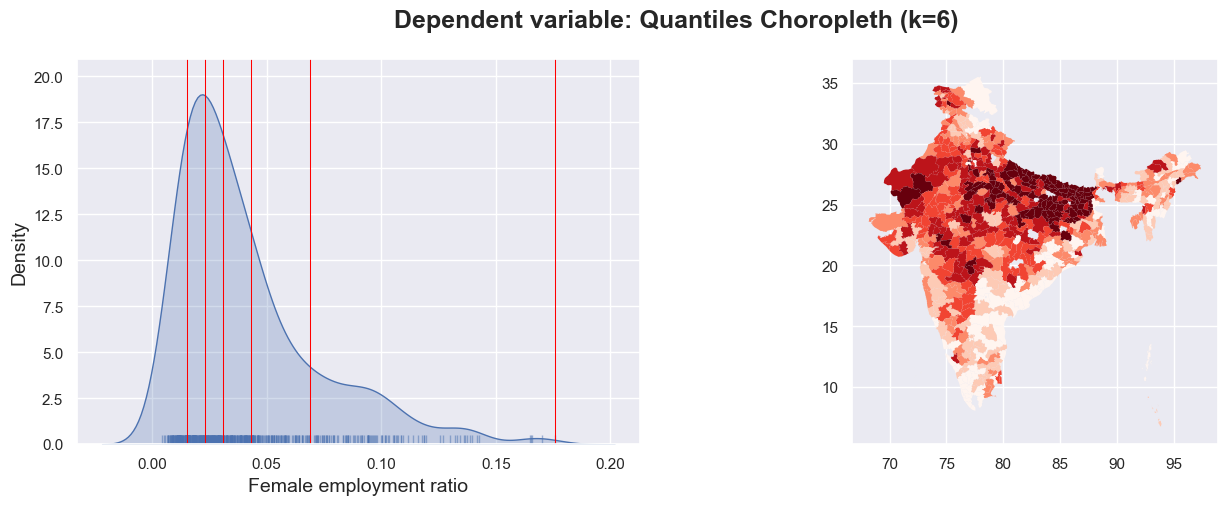

In [42]:
classi2 = mapclassify.Quantiles(subset["emp_fp"], k=6)

f, ax = plt.subplots(1, 2, figsize=(16, 5))

#KDE plot for the dependent variable
sns.kdeplot(subset["emp_fp"], fill=True, ax=ax[0])
# Add a blue tick for every value at the bottom of the plot (rugs)
sns.rugplot(subset["emp_fp"], alpha=0.5, ax=ax[0])
# Loop over each break point and plot a vertical red line
for cut in classi2.bins:
    ax[0].axvline(cut, color="red", linewidth=0.75)
ax[0].set_xlabel("Female employment ratio", fontsize=14)
ax[0].set_ylabel("Density", fontsize=14)

#KDE plot for the independent variable
subset.plot(column="emp_fp", scheme="QUANTILES", alpha=1, k=6, cmap=plt.cm.Reds_r, edgecolor="w", linewidth=0, ax=ax[1])

#Title
f.suptitle("Dependent variable: Quantiles Choropleth (k=6)", 
           fontsize=18,
           fontweight="demibold"
          )
plt.show()

**What we notice**
- The two variables have very different spatial distributions
- The independent variable has big regions with very high or very low values
- The dependent variable is more scattered

This difference in distribution suggests rejecting the hypothesis, but also that it could be useful to look at spatial autocorrelation

<br>While making the local and global autocorrelation analysis a problem occurred with the queens method matrix: the method wouldn't recognize all the districts that shared a border with a chosen district. For this reason, this analysis will opt for a KKN analysis with a high k value (k=12) to make sure that at least all confining districts are considered as neighbours. This choice could of course be very inpactful on the results.

In [43]:
w_kkn = weights.KNN.from_dataframe(geo, k=12, ids="d_id") #We build the KKN weights matrix
work = geo.copy().set_index("d_id") #We create a working copy of the dataset for the spatial analysis
w_kkn.islands #Print the indexes of the islands

[]

Since we used the KKN method, we don't have any islands. However, some phisical islands exist in India, we can see that they have the following IDs

In [44]:
islands_ids = [587,638,639,640]

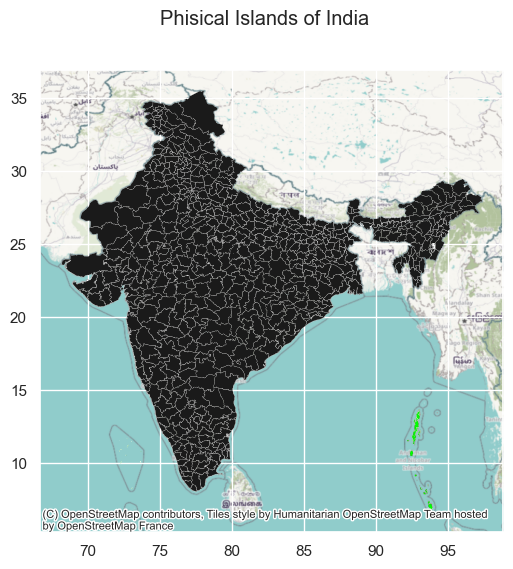

In [45]:
##### Setup figure
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot base layer of polygons
work.plot(ax=ax, facecolor="k", linewidth=0.1)
# Plot phisical islands
work.loc[islands_ids,:].plot(ax=ax, facecolor="lime", linewidth=0)

#Add basemap to show they are phisical islands
ctx.add_basemap(ax, crs=work.crs)

# Title
f.suptitle("Phisical Islands of India")
plt.show()

Let's drop those phisical islands as they don't have actual close neighbours

In [46]:
work = work.drop([587,638,639,640])

Now we can perform the autocorrelation analysis

In [47]:
#Build weight matrix again
w_kkn = weights.KNN.from_dataframe(work.reset_index(), k=12, ids="d_id")

#Row standardize the Matrix
w_kkn.transform = "R"

#Calculate spatial lag for both research variables and save as new columns
work["w_ctr_rat"] = weights.lag_spatial(w_kkn, work["ctr_rat"])
work["w_emp_fp"] = weights.lag_spatial(w_kkn, work["emp_fp"])

#Create standardized versions of research variables and save as new columns
work["std_ctr_rat"] = (work["ctr_rat"] - work["ctr_rat"].mean()) / work["ctr_rat"].std()
work["std_emp_fp"] = (work["emp_fp"] - work["emp_fp"].mean()) / work["emp_fp"].std()

#Calculate spatial lag for standardized values and save as new columns
work["w_std_ctr_rat"] = weights.lag_spatial(w_kkn, work["std_ctr_rat"])
work["w_std_emp_fp"] = weights.lag_spatial(w_kkn, work["std_emp_fp"])

This is how the new columns look like

In [48]:
work[["d_name", "ctr_rat", "w_ctr_rat", "std_ctr_rat", "w_std_ctr_rat"]].head()

,d_name,ctr_rat,w_ctr_rat,std_ctr_rat,w_std_ctr_rat
d_id,,,,,
468,Kachchh,0.000076,0.000065,-0.026646,-0.152013
469,Banas Kantha,0.000006,0.000109,-0.807468,0.340277
470,Patan,0.000102,0.000075,0.254166,-0.037380
471,Mahesana,0.000008,0.000080,-0.782885,0.016244
472,Sabar Kantha,0.000080,0.000080,0.016393,0.012278


In [49]:
work[["d_name", "emp_fp", "w_emp_fp", "std_emp_fp", "w_std_emp_fp"]].head()

,d_name,emp_fp,w_emp_fp,std_emp_fp,w_std_emp_fp
d_id,,,,,
468,Kachchh,0.036287,0.024443,-0.176254,-0.444050
469,Banas Kantha,0.018455,0.023673,-0.579426,-0.461442
470,Patan,0.024654,0.027388,-0.439261,-0.377454
471,Mahesana,0.023871,0.024868,-0.456968,-0.434421
472,Sabar Kantha,0.028815,0.023824,-0.345200,-0.458024


We can now assess global spatial autocorrelation of both variables by making a moran plot for both

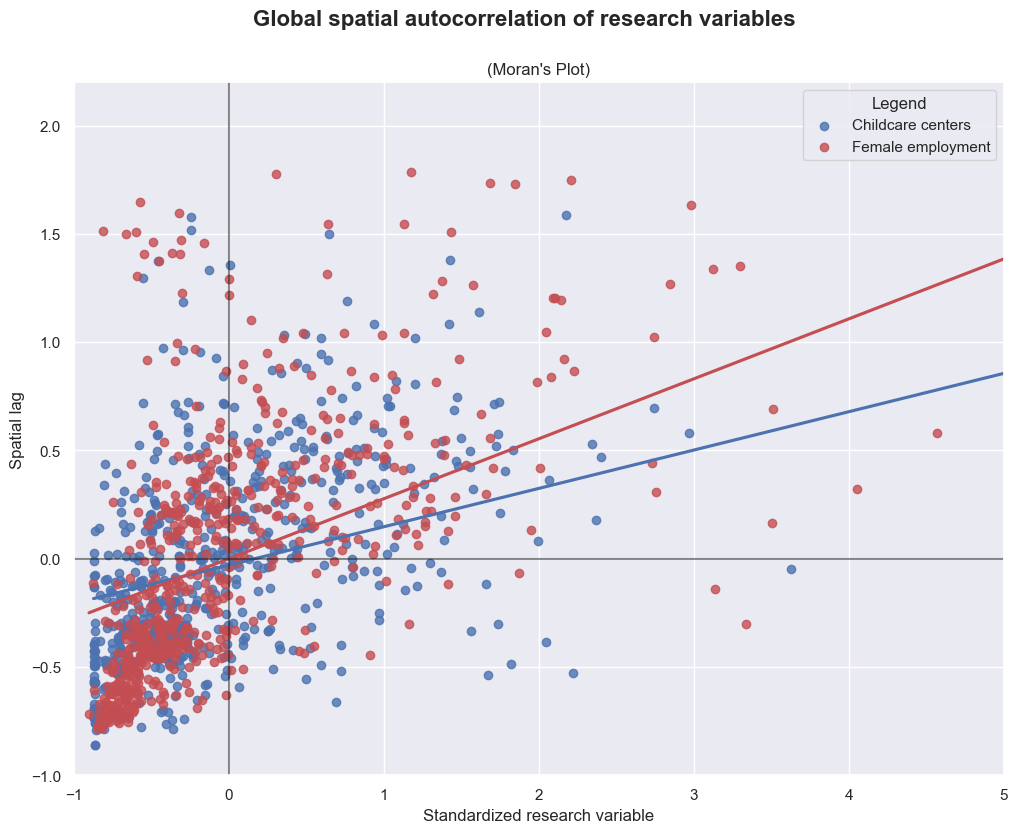

In [50]:
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(12, 9))

# Plot values
line1 = sns.regplot(x="std_ctr_rat", y="w_std_ctr_rat", data=work, ci=None, color='b', label="Childcare centers")
line2 = sns.regplot(x="std_emp_fp", y="w_std_emp_fp", data=work, ci=None, color='r', label="Female employment")

# Add vertical and horizontal lines
plt.axvline(0, c="k", alpha=0.5)
plt.axhline(0, c="k", alpha=0.5)

#Add limits to hide few outliers
ax.set_xlim(-1,5)
ax.set_ylim(-1,2.2)

#Add lables and title
ax.set_xlabel("Standardized research variable", fontsize=12)
ax.set_ylabel("Spatial lag", fontsize=12)
f.text(0.5, 0.95, "Global spatial autocorrelation of research variables", ha='center', va='center', fontsize=16, fontweight="bold")
ax.set_title("(Moran's Plot)", fontsize=12)

#Add legend
ax.legend(title="Legend")

# Display
plt.show()

**What we notice**
- Both research variables present some spatial autocorrelation
- The dependent variable shows a stronger autocorrelation

We can assess this even more by printing Morans'I and p-value for both variables

In [53]:
#Create the Moran Objects for both variables
mi_ctr = esda.Moran(work["ctr_rat"], w_kkn)
mi_emp = esda.Moran(work["emp_fp"], w_kkn)

pd.DataFrame([[mi_ctr.I, mi_emp.I],[mi_ctr.p_sim, mi_emp.p_sim]], columns=["ctr_rat","emp_fp"], index=["I","p"])

,ctr_rat,emp_fp
I,0.17707,0.276844
p,0.00100,0.001000


**What we notice**
- Both variables have I > 0.1 which confirms the presence of global autocorrelation.
- Both variables have p=0.1% which is also statically significant

We can now assess local spatial autocorrelation: we start by creating LISA objects for both variables and isolate significant observations

In [55]:
#Create LISA objects
lisa_ctr = esda.Moran_Local(work["ctr_rat"], w_kkn)
lisa_emp = esda.Moran_Local(work["emp_fp"], w_kkn)

# Break observations into significant or not
work["ctr_significant"] = lisa_ctr.p_sim < 0.05
work["emp_significant"] = lisa_emp.p_sim < 0.05

# Store the quadrant they belong to
work["ctr_quadrant"] = lisa_ctr.q
work["emp_quadrant"] = lisa_emp.q

We can now visualize local autocorrelation for both variables on the map

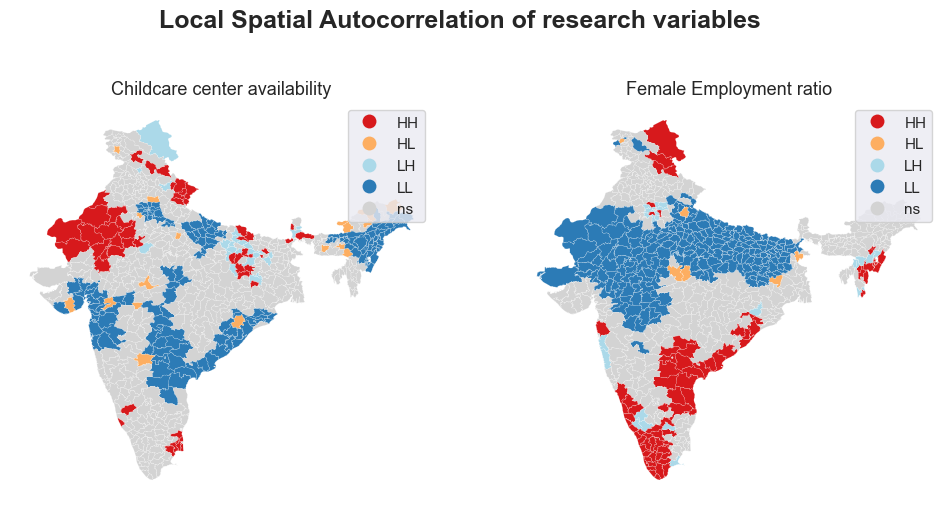

In [63]:
#Set axis
f, ax = plt.subplots(1,2, figsize=(12, 6))

#Plots
lisa_cluster(lisa_ctr, work, ax=ax[0])
lisa_cluster(lisa_emp, work, ax=ax[1])

#Titles and headers
f.suptitle("Local Spatial Autocorrelation of research variables", 
           fontsize=18,
           fontweight="demibold"
          )
ax[0].set_title("Childcare center availability", fontsize=13)
ax[1].set_title("Female Employment ratio", fontsize=13)
plt.show()

**What we notice**
- Both variables have areas of strong local autocorrelation
- The distribution of those areas is very different between the two

## Conclusions

**1. Would your analysis results change when you choose a different year for analysis?**
As mentioned in the introduction and problem statement, variables on employment are of a different year (2013) compared to the rest (2011). This could mean that the results of the analysis could be distorted. Also, some correlation between the variables was assessed, but not very strong, a big change in employment is probable (while childcare chenters take more time to change in number significantly) and could lead to significant changes in the analysis results. Spatial autocorrelation was usefull to assess which areas tend to influence each other more.

**2. Could you export your analysis framework to another country and still get reliable results?**
It depends, as mentioned in the problem statement childcare centers are a kind of proxy to maternity services overall: if in another country you have available data on these kinds of services that you can be sure you can use as a reliable broxy, the answer is yes.

**3. Motivate your final choice of variables. Did you change your set of variables compared to assignment 2? If yes, does that choice have an effect on your results and their validity?**
Variable choice was changed slightly. For how this changed improved the preciseness of the problem statement, and wich problems it introduced, see the introduction. Some more evident results were shown with this new set of variables, however, spatial analysis again tended to reject the hypothesis.

---

# Task 2

## Model choice

We assessed changes according to the presence of childcare centers already and in depth. We could build a regression model to give a clearer picture and understand the relation better between independent and dependent variables. However, we already noticwd that we have very few entries for high values of the independent variable: therefore, the regression model would not be very informative or reliable. It is more interesting to build **clusters** on the data to see which variables have a stronger impact of overall variability among districts data, but also how different districts share or don't share similarities with others.

## Variable choice and assessment

We care for quantitative data for clustering, and also we have built some variables by combining others. therefore, our variable choice will limit itself to the variables we downloaded from shrug. The others are just **linear combinations** of those variables, so they won't give any contribution to overall variance.

Let's make a list of the chosen variables and make a pairplot to see how they relate to each other

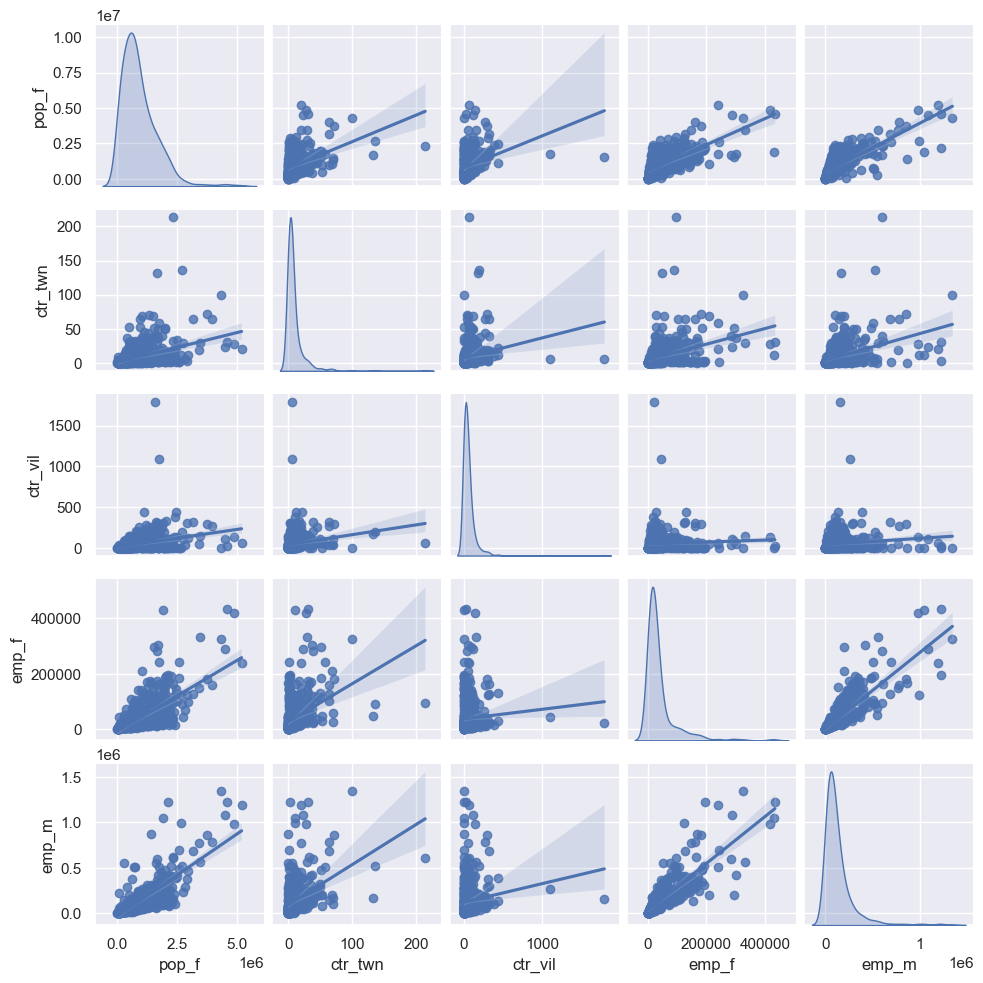

In [77]:
#Make list of selected variables
col = ["pop_f", "ctr_twn", "ctr_vil", "emp_f", "emp_m"]

# Plot values
sns.pairplot(geo[col], kind="reg", diag_kind="kde", height=2)

plt.show()

We see that some variables seem to be very corrwelated with each other. Also, we want to reduce the size of the variables used to make it easier to compute.
For these reasons we can use **Principle Component Analysis**

## PCA

First, as we see from the pairplot, the variables have very different ranges of values. It can be useful to standardize them. We won't apply normalization to avoid possible distortion to the results.

In [80]:
scaler = StandardScaler() #Making the scaler with Scikit
pca_setup_df = pd.DataFrame(scaler.fit_transform(geo[col].copy()), columns=col) #We create a seoarate working dataframe

We can now build the PCA variables and take a look at them

In [81]:
#fit the PCA to the dataset
pca = PCA().fit(pca_setup_df)

#Calculate the variables transformation
pcaX = pca.transform(pca_setup_df)

#Add names to each Principal Component
pca_cols=["PC1","PC2","PC3","PC4","PC5"]

#Make it into a dataframe and show values of the scaling values for each starting variable
pcaX_df = pd.DataFrame(pcaX, columns=pca_cols)
pcaX_df.head()

,PC1,PC2,PC3,PC4,PC5
0,0.296325,0.037591,-0.045062,0.063136,0.315784
1,0.235614,-0.404130,-0.031289,0.845188,-0.192872
2,-0.719179,0.156298,-0.211528,-0.024074,0.074211
3,-0.159489,-0.451540,0.080457,0.365636,0.162875
4,0.140957,0.346463,-0.049615,0.252427,-0.187528


We can make a dataframe with the variables contributions for each Principal Component, and for each PC also mention the explained variance for the dataset

In [83]:
variables_contribution = pd.DataFrame(pca.components_, index=pca_cols, columns=col)
variables_contribution = variables_contribution.map(np.abs)
variables_contribution["expl_variance"]=pca.explained_variance_ratio_
variables_contribution

,pop_f,ctr_twn,ctr_vil,emp_f,emp_m,expl_variance
PC1,0.525068,0.360077,0.175453,0.517404,0.544203,0.575838
PC2,0.059755,0.172938,0.920438,0.279187,0.203395,0.201738
PC3,0.240998,0.916327,0.234799,0.133141,0.171488,0.142039
PC4,0.734568,0.027816,0.253927,0.626666,0.049472,0.053732
PC5,0.350803,0.002852,0.048989,0.493874,0.794114,0.026652


A better way to visualize contributions for each variable is to make a heatmap

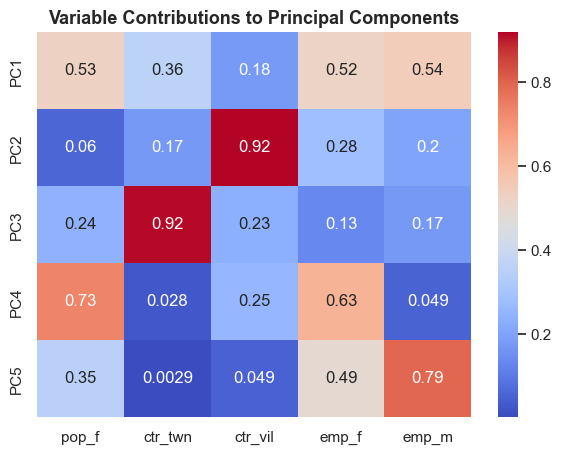

In [86]:
plt.figure(figsize=(7, 5))

sns.heatmap(variables_contribution[col], annot=True, cmap="coolwarm")

plt.title("Variables Contributions to Principal Components", fontweight="bold", fontsize=13)
plt.show()

**NOTE** the number of childcare centers show little contribution to overall variance as the have very low contribution in the most relevant PC. This could mean that the variables are highly correlated with the others. 

This is important because their role as the **independent variable** is put to doubt

## Clustering

Let's start the proper clustering: we will use the first three PC that explain more than 90% of the variance to reduce computing load


We will use a Kmeans method.
Let's build a working df for the clustering


In [88]:
pca_cols = pca_cols[0:3] #Isolate working PCs

#Create clustering df
pca_cl_df = pd.concat([geo[["d_id", "geometry"]].copy(), pcaX_df[pca_cols]], axis=1).set_index("d_id")

#Rearrange columns
pca_cl_df = pca_cl_df[pca_cols + ["geometry"]]

#Print df
pca_cl_df.head()

,PC1,PC2,PC3,geometry
d_id,,,,
468,0.296325,0.037591,-0.045062,"MULTIPOLYGON (((70.45008 23.01226, 70.44904 23..."
469,0.235614,-0.404130,-0.031289,"MULTIPOLYGON (((71.24964 24.20926, 71.24207 24..."
470,-0.719179,0.156298,-0.211528,"MULTIPOLYGON (((71.42507 23.96967, 71.42497 23..."
471,-0.159489,-0.451540,0.080457,"POLYGON ((72.79975 24.07615, 72.80022 24.07529..."
472,0.140957,0.346463,-0.049615,"POLYGON ((73.14784 24.47759, 73.14773 24.4741,..."


We will use the elbow method to assess the best value of k

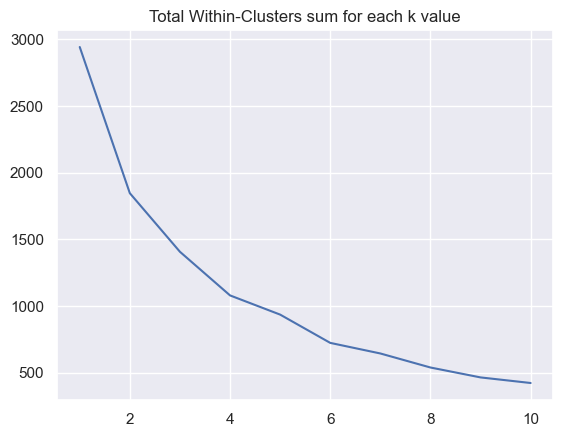

In [95]:
#Perform elbow method

#Initialize vectors for the kmeans value
TWCV = []
kmeans = []
kcls = []
index=[]

for i in range(10):
    kmeans.append(cluster.KMeans(n_clusters=i+1))
    kcls.append(kmeans[i].fit(pcaX_df[pca_cols]))
    TWCV.append(kcls[i].inertia_)
    index.append(i+1)

pd.Series(TWCV,index=index).plot(title="Total Within-Clusters sum for each k value")
plt.show()

We can choose a value of k=4 from the plot and perform the kmeans clustering

In [104]:
k4cls = kcls[3]
pd.Series(k4cls.labels_).value_counts()

0    443
3    171
1     24
2      2
Name: count, dtype: int64

The counts are not proportinate but still significant except for cluster 2: we can consider those as potential outliers. We can create a new working dataframe for visualization (the one we are using is standardized) and add a cluster column

In [105]:
cl_gdf = geo.copy()
cl_gdf["cluster"] = k4cls.labels_

Let's see if we can see the clusters properly by building a scatter plot of the two most contributing variables

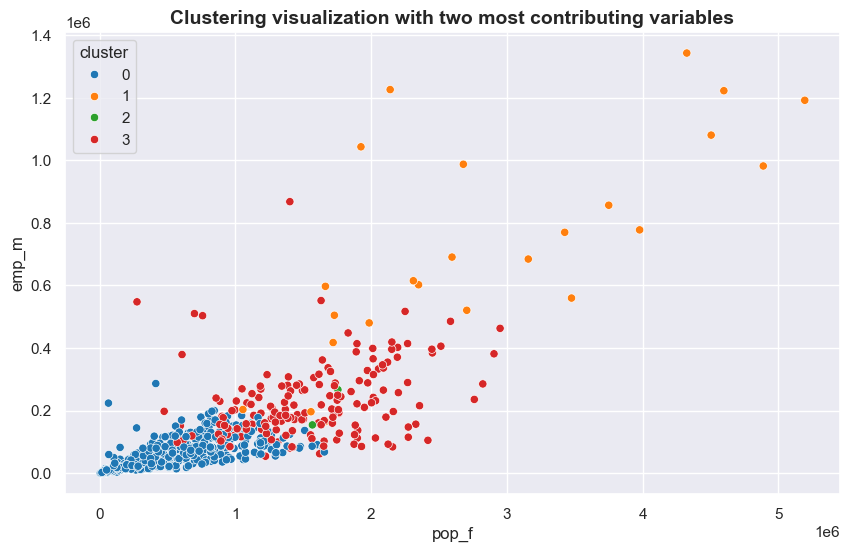

In [106]:
f, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.scatterplot(data=cl_gdf, x="pop_f", y="emp_m", hue="cluster", ax=ax, palette="tab10")
ax.set_title("Clustering visualization with two most contributing variables", fontsize = 14, fontweight="bold")
plt.show()

We can see the clusters well: now let's plot the average value of each variable for each value so that we can see how clusters differ from each other

In [107]:
cl_gdf.groupby("cluster")[col + ["ctr_sum","ctr_rat","emp_fp"]].mean()

,pop_f,ctr_twn,ctr_vil,emp_f,emp_m,ctr_sum,ctr_rat,emp_fp
cluster,,,,,,,,
0,5.635770e+05,4.374718,34.000000,16532.665914,63591.600451,38.374718,0.000078,0.039631
1,2.890690e+06,53.750000,92.958333,231847.500000,738242.833333,146.708333,0.000057,0.092934
2,1.660928e+06,5.500000,1445.000000,33222.000000,210620.000000,1450.500000,0.000888,0.019671
3,1.550680e+06,14.122807,91.929825,69163.081871,227141.719298,106.052632,0.000075,0.049964


## Conclusions

1. Childcare centers are not appropriate as independent variables by themselves as they are highly correlated with others (from the pairplot we see it's mostly female population: indeed in task 2 we used the ratio instead of the absolute number of centers)
2. There are a very small number of district with high population: these districts have a very low availability of childcare centers. This could mean that highly populated districts don't have the resources to make a high amount of centers (or they make bigger ones in towns, as the number of town centers is really high). But they also have a high female employment ratio
3. Low populated areas  have lower employment but more centers.
4. There are some outliar districts with weird values

To coclude, female employment is probably not very highly correlated to availability of childcare centers, or their number, as probably other factors concurr more to its growth and centers could vary in size (especially town centers could be much bigger).

# Task 3

To conclude, we can make some critical questions on the approach to the analysis and its results

**Where are the highest sources of errors and biases?**
- Variable choice (especially the choice of childcare cenetrs as independent, even with the improvement of adding the town centers)
- Methods (KKN for weight matrix and the elbow methods)
- Number of variables for clustering (see below)
- Difference in years for variables

**Which are the strengths of the analysis?**
- The analysis has improved compared to assignment 2, especially because of the new variable choice (see problem statement)
- The analysis uses very different types of visualizations and makes comparisons between different variables
- The choice of clustering gave many additional insights (especially on variables relevance and for the conclusions)

**What could help the analysis to improve?**
- Including many variables from the SHRUG downloaded datasets could enhance the clustering process, giving even more insights on variables relations and creating more informative clusters
- Performing an analysis on different times (for example including data from other census years) could give better understaning on the changes and the growth of employment and childcare services (also to identify better performing districts and states)
- If SHRUG had a specific section of childcare and maternity welfare services the analysis could benefit highly of it

Overall, the analysis has on most fronts **rejected the hypothesis**, especially on spatial terms, but suggesting that by adjusting the variable choice even more and reducing the set of assumptions, some useful insights could be obtained. Such insights could be very useful for identifying means of improvement for societal conditions, and the analysis could be performed on other areas to identify recurring patterns and more effective strategies.